# 04 - DPO 数据分析

## DPO 的核心思想

DPO（Direct Preference Optimization）的训练数据格式：

```
{prompt, chosen_response, rejected_response}
```

模型学习：在给定 prompt 下，提高生成 chosen 的概率，降低生成 rejected 的概率。

### Tülu 3 的 DPO 数据构造

Tülu 3 使用 **on-policy** 数据生成策略：
1. 用 SFT 模型对 prompt 生成多个候选回答
2. 用 reward model 对候选回答打分
3. 选最高分作 chosen，最低分作 rejected

本 Notebook 分析 DPO 数据的质量和特征。

In [1]:
import json
import sys
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Arial Unicode MS', 'sans-serif']
import numpy as np

PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

# 加载 DPO 数据
dpo_path = PROJECT_ROOT / "data/dpo_mix/train.jsonl"
dpo_samples = []
with open(dpo_path, "r") as f:
    for line in f:
        if line.strip():
            dpo_samples.append(json.loads(line))

print(f"DPO 数据总量: {len(dpo_samples):,} 对")
print(f"字段: {list(dpo_samples[0].keys())}")

DPO 数据总量: 1,000 对
字段: ['prompt', 'chosen', 'rejected', 'source']


In [2]:
# 依赖文件校验（§2.2）
REQUIRED_FILES = ["data/dpo_mix/train.jsonl"]
for f in REQUIRED_FILES:
    assert (PROJECT_ROOT / f).exists(), f"缺少: {f}，请先运行 scripts/run_download.py"
print("依赖文件校验通过 ✓")

依赖文件校验通过 ✓


## A. Chosen vs Rejected 长度对比

通常 chosen（好的回答）比 rejected（差的回答）更长、更详细。

In [3]:
# 计算长度统计
chosen_lens = [len(s["chosen"].split()) for s in dpo_samples]
rejected_lens = [len(s["rejected"].split()) for s in dpo_samples]
prompt_lens = [len(s["prompt"].split()) for s in dpo_samples]

print("长度统计 (words):")
print(f"  Prompt:   mean={np.mean(prompt_lens):.0f}, median={np.median(prompt_lens):.0f}, max={np.max(prompt_lens)}")
print(f"  Chosen:   mean={np.mean(chosen_lens):.0f}, median={np.median(chosen_lens):.0f}, max={np.max(chosen_lens)}")
print(f"  Rejected: mean={np.mean(rejected_lens):.0f}, median={np.median(rejected_lens):.0f}, max={np.max(rejected_lens)}")

# Chosen 比 Rejected 长的比例
chosen_longer = sum(1 for c, r in zip(chosen_lens, rejected_lens) if c > r)
print(f"\nChosen 比 Rejected 长的比例: {chosen_longer/len(dpo_samples)*100:.1f}%")

长度统计 (words):
  Prompt:   mean=204, median=94, max=2900
  Chosen:   mean=203, median=100, max=2983
  Rejected: mean=198, median=70, max=5414

Chosen 比 Rejected 长的比例: 59.1%


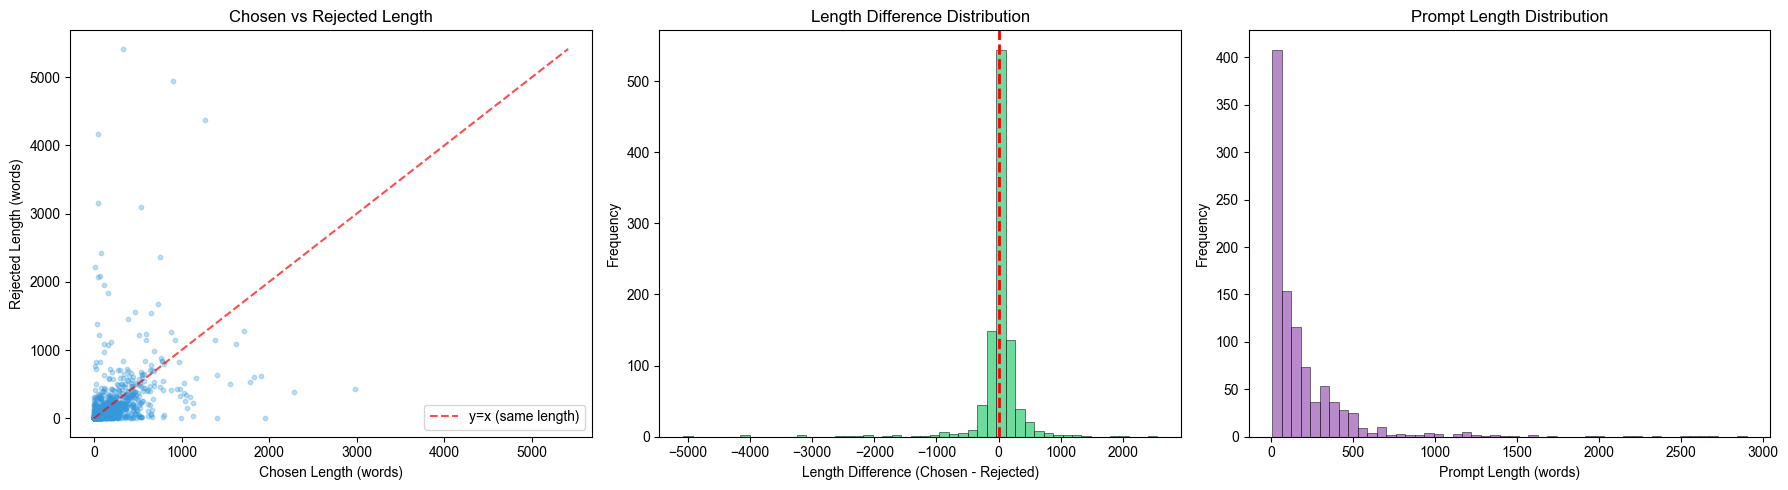

Saved to results/figures/dpo_data_analysis.png


In [4]:
# 长度分布可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chosen vs Rejected 长度散点图
axes[0].scatter(chosen_lens, rejected_lens, alpha=0.3, s=10, color='#3498DB')
max_len = max(max(chosen_lens), max(rejected_lens))
axes[0].plot([0, max_len], [0, max_len], 'r--', label='y=x (same length)', alpha=0.7)
axes[0].set_xlabel('Chosen Length (words)')
axes[0].set_ylabel('Rejected Length (words)')
axes[0].set_title('Chosen vs Rejected Length', fontweight='bold')
axes[0].legend()

# 长度差分布
length_diffs = [c - r for c, r in zip(chosen_lens, rejected_lens)]
axes[1].hist(length_diffs, bins=50, color='#2ECC71', edgecolor='black', linewidth=0.5, alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Length Difference (Chosen - Rejected)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Length Difference Distribution', fontweight='bold')

# Prompt 长度分布
axes[2].hist(prompt_lens, bins=50, color='#9B59B6', edgecolor='black', linewidth=0.5, alpha=0.7)
axes[2].set_xlabel('Prompt Length (words)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Prompt Length Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'results/figures/dpo_data_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/figures/dpo_data_analysis.png")

## B. 样本深度分析：Chosen vs Rejected 的质量差异

让我们看几个具体的 (prompt, chosen, rejected) 三元组，
理解 DPO 到底在学什么。

In [5]:
import random
random.seed(42)

# 展示 5 个样本
display_samples = random.sample(dpo_samples, min(5, len(dpo_samples)))

for i, sample in enumerate(display_samples):
    print(f"{'='*70}")
    print(f"样本 {i+1}")
    print(f"{'='*70}")
    print(f"Source: {sample.get('source', 'N/A')}")
    print(f"\nPrompt ({len(sample['prompt'].split())} words):")
    print(f"  {sample['prompt'][:200]}..." if len(sample['prompt']) > 200 else f"  {sample['prompt']}")
    print(f"\nChosen ({len(sample['chosen'].split())} words):")
    print(f"  {sample['chosen'][:200]}..." if len(sample['chosen']) > 200 else f"  {sample['chosen']}")
    print(f"\nRejected ({len(sample['rejected'].split())} words):")
    print(f"  {sample['rejected'][:200]}..." if len(sample['rejected']) > 200 else f"  {sample['rejected']}")
    print()

样本 1
Source: allenai/tulu-3-sft-reused-if

Prompt (93 words):
  You're planning a hiking trip in the Himalayas and need to pack light as you'll be carrying your own backpack. The trek will last for 10 days, and you'll be camping each night. The temperature will ra...

Chosen (327 words):
  For your Himalayan hiking trip, an optimal packing list would include the following essentials, focusing on warmth, durability, and functionality:

**Baselayer:** 
- **Merino wool or synthetic base la...

Rejected (844 words):
  Certainly! Given your requirements for a 10-day trek in the Himalayas facing varying temperatures and potential snow, I have put together a packing list designed to be as thoughtful and practical as p...

样本 2
Source: allenai/tulu-3-sft-reused-if

Prompt (33 words):
  Do not include keywords neohexane, lignitiferous, sebright in the response. Rewrite the instructions given to the recruiters while recruiting new interns.
Recruiting new interns involves reviewing res...

Chosen

## C. DPO 数据来源分布

Tülu 3 的 DPO 数据来自多个领域的偏好对。

DPO 数据来源分布:
  allenai/tulu-3-sft-reused-if: 1000 (100.0%)


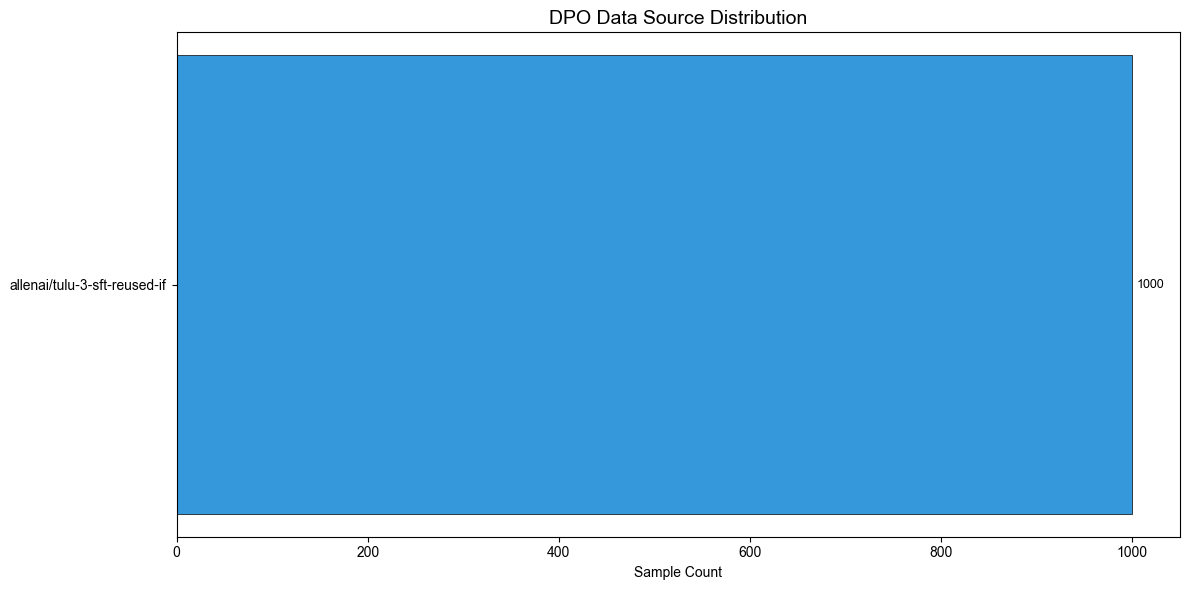

In [6]:
# Source 分布
source_counts = Counter(s.get("source", "unknown") for s in dpo_samples)
print("DPO 数据来源分布:")
for source, count in source_counts.most_common():
    print(f"  {source}: {count} ({count/len(dpo_samples)*100:.1f}%)")

# 可视化
fig, ax = plt.subplots(figsize=(12, 6))
sorted_items = sorted(source_counts.items(), key=lambda x: -x[1])
names = [item[0][:30] for item in sorted_items]
counts = [item[1] for item in sorted_items]

bars = ax.barh(names, counts, color='#3498DB', edgecolor='black', linewidth=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{count}', va='center', fontsize=9)

ax.set_xlabel('Sample Count')
ax.set_title('DPO Data Source Distribution', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'results/figures/dpo_source_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## D. DPO 的数学直觉

### DPO Loss 公式

$$\mathcal{L}_{DPO} = -\mathbb{E}\left[\log \sigma\left(\beta \cdot \left(\log \frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \log \frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}\right)\right)\right]$$

其中：
- $y_w$ = chosen (winning) response
- $y_l$ = rejected (losing) response
- $\pi_\theta$ = 正在训练的模型
- $\pi_{ref}$ = 参考模型 (frozen SFT)
- $\beta$ = KL 散度惩罚系数 (Tülu 3 用 $\beta=5$)

### 直觉理解

DPO 做的事情：
1. **提高** chosen 的概率（相对于参考模型）
2. **降低** rejected 的概率（相对于参考模型）
3. **$\beta$ 越大**，越不敢偏离参考模型 → 更保守
4. **$\beta$ 越小**，越大胆改变 → 可能过拟合

### 为什么 Tülu 3 用 $\beta=5$（比常见的 $\beta=0.1$ 大很多）？

Tülu 3 发现：较大的 $\beta$ 可以防止模型在 DPO 训练中 "忘记" SFT 学到的能力。
这是一个重要的 engineering insight：DPO 训练需要谨慎调节 $\beta$。

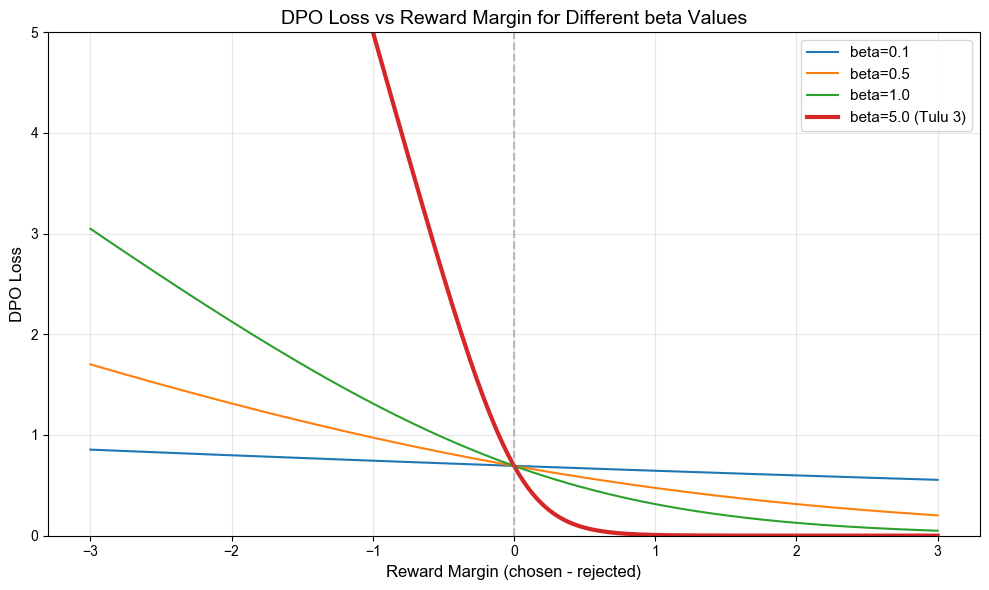

Saved to results/figures/dpo_beta_analysis.png


In [7]:
# 可视化 beta 对 DPO loss 的影响
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

# 模拟 reward margin (chosen_logprob - rejected_logprob)
margins = np.linspace(-3, 3, 200)

for beta in [0.1, 0.5, 1.0, 5.0]:
    loss = -np.log(1 / (1 + np.exp(-beta * margins)))
    label = f'beta={beta}' + (' (Tulu 3)' if beta == 5.0 else '')
    linewidth = 3 if beta == 5.0 else 1.5
    ax.plot(margins, loss, linewidth=linewidth, label=label)

ax.set_xlabel('Reward Margin (chosen - rejected)', fontsize=12)
ax.set_ylabel('DPO Loss', fontsize=12)
ax.set_title('DPO Loss vs Reward Margin for Different beta Values', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'results/figures/dpo_beta_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/figures/dpo_beta_analysis.png")

## E. 关键要点

1. **DPO 数据质量直接影响最终模型质量** — chosen/rejected 的差异越清晰，模型学得越好
2. **Chosen 通常更长更详细** — 但长度不是唯一的质量指标
3. **$\beta=5$ 是 Tülu 3 的重要发现** — 比学术界常用值大 50 倍，防止能力退化
4. **On-policy 数据生成** — 用 SFT 模型自己生成候选，比 off-policy 数据更有效

### 下一步

→ **Notebook 05**：DPO 训练，观察 reward margin 曲线和 SFT vs DPO 对比